# Lesson 1: An Introduction to Psychophysical Modelling

## What is psychophysics?

**Psychophysics** studies the quantitative relationship between physical stimuli and the
perceptions or decisions they produce.  The key insight is that perception is not
deterministic: the same physical stimulus does not always produce the same internal
representation.  Noise — arising from photoreceptor variability, neural transmission,
working memory limitations, and random fluctuations throughout the sensory hierarchy —
means that every measurement is uncertain.

A **psychophysical model** formalises this noise to link three things:
1. The **stimulus** (a physical quantity such as the number of dots on a screen).
2. The **internal representation** (a noisy encoding of the stimulus).
3. The **response** (a forced choice, a rating, a reaction time).

By fitting such a model to behavioural data we can *infer* parameters that are not
directly observable — things like how much noise the brain adds to a given stimulus, or
what prior beliefs the observer brings into the experiment.  This inference is what
separates psychophysical modelling from simple curve-fitting: we get **posterior
distributions** over interpretable parameters, with proper uncertainty quantification.

## The bauer library

**bauer** (*B*ayesian Estimation of Perceptu*a*l, N*u*merical and *R*isky Choic*e*)
is a Python library that makes hierarchical Bayesian psychophysical modelling easy.
It is built on [PyMC](https://www.pymc.io) and [ArviZ](https://python.arviz.org) and
provides:

- Ready-to-use model classes for **magnitude comparison**, **psychometric functions**,
  and **risky choice** — no need to hand-code PyMC models.
- **Hierarchical fitting** by default: each participant gets their own parameters, but
  they are regularised by a shared group-level distribution.
- **Regression support** via patsy formulas — e.g. `regressors={'nu': 'C(condition)'}` to
  estimate noise separately per condition.
- **Posterior predictive checks** (PPC) with a single `model.ppc(data, idata)` call.
- Full **ArviZ** integration for trace diagnostics, HDI plots, ELPD comparison, and more.

In these tutorials we walk through the main model families, starting from first principles.

## The Noisy Logarithmic Coding (NLC) model

When we judge quantities — the number of coins in a pile, the size of a reward — our
internal representations are noisy.  The **NLC model** posits that the brain encodes
numerical magnitude $n$ on a **logarithmic** scale, and that this log-representation is
corrupted by Gaussian noise:

$$r \sim \mathcal{N}(\log n, \; \nu^2)$$

The logarithmic encoding has two important consequences:

1. **Weber's law** falls out automatically.  Because the noise $\nu$ is constant on a
   log scale, the *absolute* noise on the original scale grows in proportion to the
   magnitude: equal log-space noise means proportionally larger linear-space uncertainty
   for big numbers than for small ones.

2. **Scale invariance**: when we plot the psychometric function against the log-ratio
   $\log(n_2/n_1)$, all curves for different reference magnitudes $n_1$ collapse onto a
   single sigmoid.  This is a direct and falsifiable prediction of the model.

### The decision rule

Given two stimuli $n_1$ and $n_2$ with independent log-space noise, the probability of
choosing $n_2$ as the larger is

$$P(\text{chose}\; n_2) = \Phi\!\left(\frac{\log(n_2/n_1)}{\sqrt{\nu_1^2 + \nu_2^2}}\right)$$

where $\Phi$ is the standard normal CDF, $\nu_1$ is the noise on $n_1$ (the first-presented
option) and $\nu_2$ is the noise on $n_2$ (the second-presented option).

In tasks where stimuli are shown **sequentially** (the observer perceives $n_1$, holds it
in working memory, then perceives $n_2$), memory retention may add noise.  The model
therefore allows $\nu_1 \neq \nu_2$.  In simultaneous-presentation tasks a single shared
$\nu$ is sufficient.

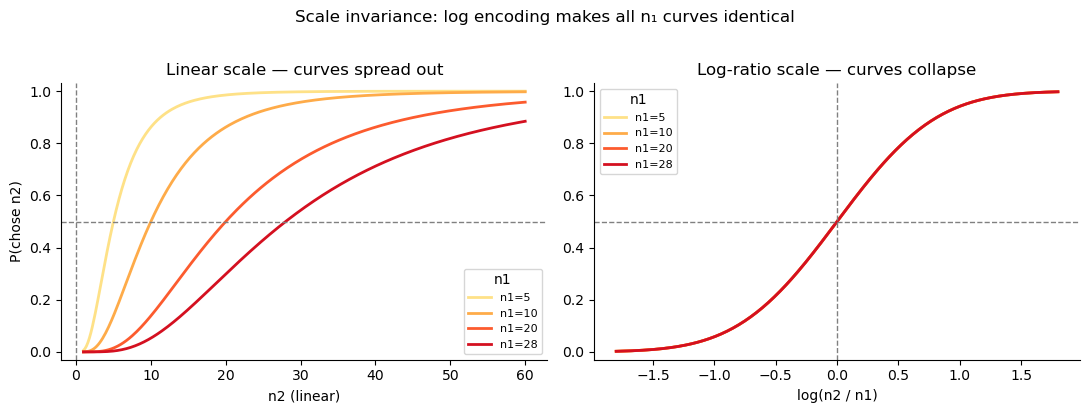

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm as scipy_norm

# ── Scale invariance demo ─────────────────────────────────────────────────────
nu = 0.45                              # equal noise for both options
n1_vals = [5, 10, 20, 28]
n2_linear = np.linspace(1, 60, 300)
log_ratios = np.linspace(-1.8, 1.8, 300)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
pal = sns.color_palette('YlOrRd', len(n1_vals))

for (n1, c) in zip(n1_vals, pal):
    p_lin = scipy_norm.cdf(np.log(n2_linear / n1) / (np.sqrt(2) * nu))
    p_log = scipy_norm.cdf(log_ratios            / (np.sqrt(2) * nu))
    axes[0].plot(n2_linear, p_lin, color=c, lw=2, label=f'n1={n1}')
    axes[1].plot(log_ratios, p_log, color=c, lw=2, label=f'n1={n1}')

for ax in axes:
    ax.axhline(0.5, ls='--', c='gray', lw=1)
    ax.set_ylim(-0.03, 1.03)
    ax.legend(title='n1', fontsize=8)
    sns.despine(ax=ax)

axes[0].axvline(0, ls='--', c='gray', lw=1)
axes[1].axvline(0, ls='--', c='gray', lw=1)
axes[0].set_xlabel('n2 (linear)')
axes[1].set_xlabel('log(n2 / n1)')
axes[0].set_ylabel('P(chose n2)')
axes[0].set_title('Linear scale — curves spread out')
axes[1].set_title('Log-ratio scale — curves collapse')
plt.suptitle('Scale invariance: log encoding makes all n₁ curves identical', y=1.02)
plt.tight_layout()

## The psychometric function: noise, precision, and asymmetry

### 1. Noise level controls the slope

The slope of the psychometric function is entirely determined by the **combined noise**
$\sigma_\text{total} = \sqrt{\nu_1^2 + \nu_2^2}$.  More noise → shallower curve →
worse discrimination.  The left panel below illustrates this for equal noise on both
options ($\nu_1 = \nu_2 = \nu$).

### 2. Asymmetric noise flattens but does not shift the curve

When one option is noisier than the other — for instance because $n_1$ was encoded a few
seconds ago and is now degraded in working memory — the midpoint of the curve
($P = 0.5$ at $\log(n_2/n_1) = 0$) does not shift: **asymmetric noise alone does not
produce a bias**, it just makes discrimination harder.

The right panel illustrates a subtlety: even when the *total* noise budget $\nu_1 + \nu_2$
is held constant, redistributing it unequally raises
$\sigma_\text{total} = \sqrt{\nu_1^2 + \nu_2^2}$ (by Cauchy-Schwarz, this is minimised
when $\nu_1 = \nu_2$).  So working-memory degradation does not just "move" noise from
one option to the other — it genuinely costs precision.

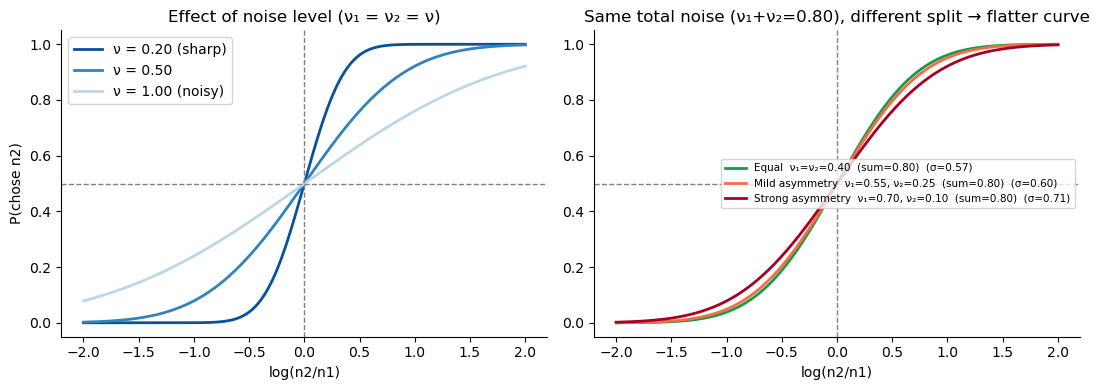

In [2]:
log_r = np.linspace(-2, 2, 300)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: noise level → precision (equal noise on both options)
ax = axes[0]
for nu_val, label, c in [(.2, 'ν = 0.20 (sharp)', '#08519c'),
                           (.5, 'ν = 0.50', '#3182bd'),
                           (1., 'ν = 1.00 (noisy)', '#bdd7e7')]:
    sigma = np.sqrt(2) * nu_val   # nu1 = nu2 = nu_val
    ax.plot(log_r, scipy_norm.cdf(log_r / sigma), lw=2, color=c, label=label)
ax.axhline(.5, ls='--', c='gray', lw=1); ax.axvline(0, ls='--', c='gray', lw=1)
ax.set_xlabel('log(n2/n1)'); ax.set_ylabel('P(chose n2)')
ax.set_title('Effect of noise level (ν₁ = ν₂ = ν)')
ax.legend(); sns.despine(ax=ax)

# Right: same total noise budget ν₁ + ν₂ = 0.80, but distributed differently
# Key: σ_total = √(ν₁² + ν₂²) is MINIMISED when ν₁ = ν₂ (Cauchy-Schwarz).
# So asymmetric noise → higher σ_total → flatter curve, even at equal total.
ax = axes[1]
cases = [
    (0.4, 0.4, 'Equal  ν₁=ν₂=0.40  (sum=0.80)', '#1a9850'),
    (0.55, 0.25, 'Mild asymmetry  ν₁=0.55, ν₂=0.25  (sum=0.80)', '#f46d43'),
    (0.7, 0.1, 'Strong asymmetry  ν₁=0.70, ν₂=0.10  (sum=0.80)', '#a50026'),
]
for nu1, nu2, label, c in cases:
    sigma = np.sqrt(nu1**2 + nu2**2)
    ax.plot(log_r, scipy_norm.cdf(log_r / sigma), lw=2, color=c,
            label=f'{label}  (σ={sigma:.2f})')
ax.axhline(.5, ls='--', c='gray', lw=1); ax.axvline(0, ls='--', c='gray', lw=1)
ax.set_xlabel('log(n2/n1)')
ax.set_title('Same total noise (ν₁+ν₂=0.80), different split → flatter curve')
ax.legend(fontsize=7.5); sns.despine(ax=ax)

plt.tight_layout()

## Bayesian inference and the central tendency bias

### The Bayesian observer

The NLC observer does not simply report the noisy measurement $r = \log n + \epsilon$.
Instead, they act as an **ideal Bayesian observer**: they combine the noisy evidence with
a **prior** belief about what magnitudes are likely to appear in the experiment.  If the
prior is $\mathcal{N}(\mu_0, \sigma_0^2)$ and the likelihood is
$\mathcal{N}(\log n, \nu^2)$, Bayes' rule gives a Gaussian posterior:

$$\hat\mu = \underbrace{\frac{\sigma_0^2}{\sigma_0^2 + \nu^2}}_{\gamma}\, r
           + (1-\gamma)\,\mu_0, \qquad
\hat\sigma^2 = \frac{\sigma_0^2\,\nu^2}{\sigma_0^2 + \nu^2}$$

The posterior mean $\hat\mu$ is a **weighted average** of the raw evidence $r$ and the
prior mean $\mu_0$.  The weight given to the prior, $1 - \gamma$, is larger when the
noise $\nu$ is large (the evidence is unreliable) or the prior is narrow (the observer is
confident about the range of stimuli).

### Central tendency bias

Because the prior pulls representations toward $\mu_0$, stimuli larger than $\mu_0$ are
**underestimated** and stimuli smaller than $\mu_0$ are **overestimated**.  This
systematic compression toward the prior mean is the **central tendency effect** — a
well-documented perceptual bias.

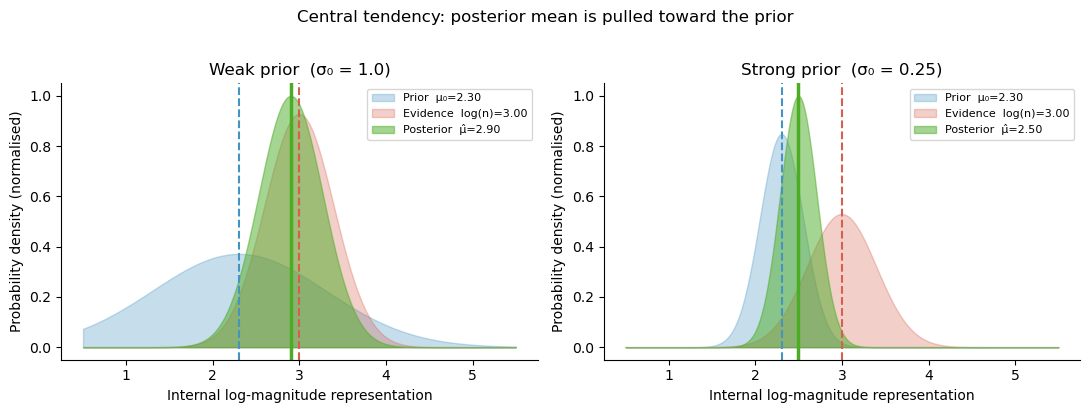

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

x = np.linspace(0.5, 5.5, 400)       # log-magnitude axis
log_n_true  = np.log(20)              # true stimulus: n=20
prior_mu    = np.log(10)              # prior centred at n=10
nu          = 0.4                     # measurement noise

for ax, (prior_sd, title) in zip(axes,
        [(1.0, 'Weak prior  (σ₀ = 1.0)'),
         (0.25, 'Strong prior  (σ₀ = 0.25)')]):

    gamma   = prior_sd**2 / (prior_sd**2 + nu**2)
    post_mu = prior_mu + gamma * (log_n_true - prior_mu)
    post_sd = np.sqrt(prior_sd**2 * nu**2 / (prior_sd**2 + nu**2))

    like  = scipy_norm.pdf(x, log_n_true, nu)
    prior = scipy_norm.pdf(x, prior_mu,  prior_sd)
    post  = scipy_norm.pdf(x, post_mu,   post_sd)
    mx    = max(like.max(), prior.max(), post.max())

    ax.fill_between(x, prior/mx, alpha=.3, color='#4393c3', label=f'Prior  μ₀={prior_mu:.2f}')
    ax.fill_between(x, like/mx,  alpha=.3, color='#d6604d', label=f'Evidence  log(n)={log_n_true:.2f}')
    ax.fill_between(x, post/mx,  alpha=.5, color='#4dac26', label=f'Posterior  μ̂={post_mu:.2f}')
    ax.axvline(log_n_true, ls='--', c='#d6604d', lw=1.5)
    ax.axvline(prior_mu,   ls='--', c='#4393c3', lw=1.5)
    ax.axvline(post_mu,    ls='-',  c='#4dac26', lw=2.5)
    ax.set_xlabel('Internal log-magnitude representation')
    ax.set_ylabel('Probability density (normalised)')
    ax.set_title(title)
    ax.legend(fontsize=8)
    sns.despine(ax=ax)

plt.suptitle('Central tendency: posterior mean is pulled toward the prior', y=1.02)
plt.tight_layout()

### Why asymmetric noise creates magnitude–order interactions

In a sequential task, $n_1$ is noisier than $n_2$ because of memory degradation:
$\nu_1 > \nu_2$.  The Bayesian posterior mean is

$$\hat\mu_k = \gamma_k \log n_k + (1-\gamma_k)\mu_0,
\quad \gamma_k = \frac{\sigma_0^2}{\sigma_0^2 + \nu_k^2}$$

The weight $\gamma_k$ is **different** for the two options whenever $\nu_1 \neq \nu_2$.

- The **noisier** option (usually $n_1$) gets a smaller weight $\gamma_1$, meaning its
  posterior is pulled *more* toward $\mu_0$.
- The **less noisy** option (usually $n_2$) gets a larger weight $\gamma_2$ and is
  pulled *less* toward $\mu_0$.

If $\mu_0$ is set to the mean of the log-stimulus distribution, then large stimuli are
underestimated and small stimuli are overestimated.  Because $n_1$ is underestimated
*more* than $n_2$, the observer is effectively biased **toward choosing $n_2$** when
both are large (big $n_1$ is shrunk, making $n_2$ look relatively bigger), and
**against choosing $n_2$** when both are small (small $n_1$ is inflated, making $n_2$
look relatively smaller).

**This is the source of the magnitude–order interaction**: it is not asymmetric noise
per se that causes it, but asymmetric noise interacting with a Bayesian prior that
compresses different options by different amounts.  Equal noise on both options would
produce a uniform shift of the midpoint — no interaction with the reference magnitude.

The NLC model captures all of this with just three parameters per subject: $\nu_1$,
$\nu_2$, and $\sigma_0$ (prior width).

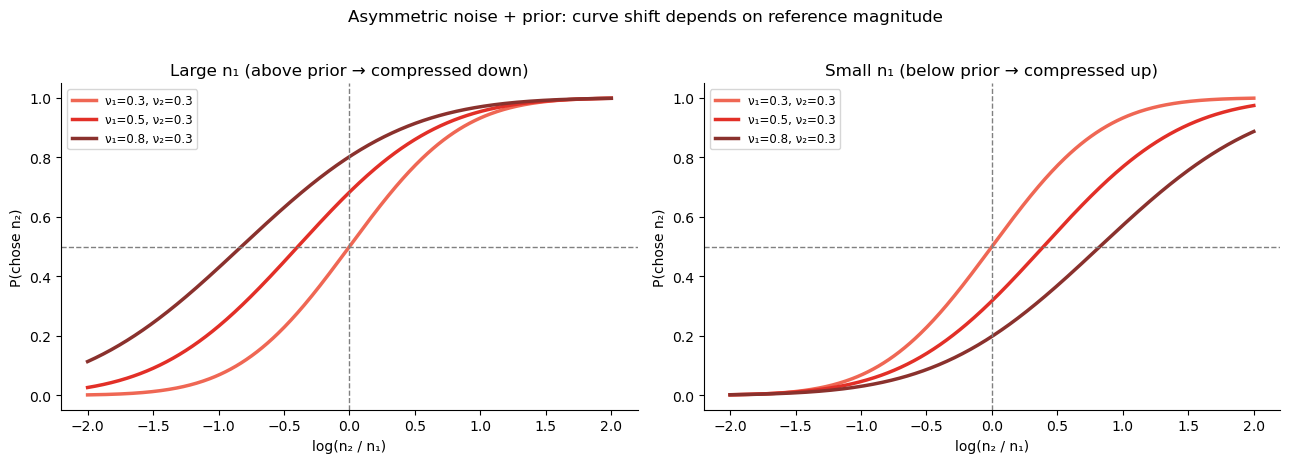

In [4]:
# Illustrate the interaction: how the choice bias changes with n1 and noise asymmetry
log_r_range = np.linspace(-2, 2, 400)
nu1_values  = [0.3, 0.5, 0.8]   # increasing memory noise on n1
nu2         = 0.3                # fixed perceptual noise on n2
prior_sd    = 0.6                # moderate prior
prior_mu    = 0.0                # centred (mean of log-stimulus distribution)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
pal = sns.color_palette('Reds_d', len(nu1_values))

# Left: large n1 (above prior mean); Right: small n1 (below prior mean)
for ax, log_n1, n1_label in zip(axes, [1.5, -1.5],
        ['Large n₁ (above prior → compressed down)',
         'Small n₁ (below prior → compressed up)']):
    for nu1, c in zip(nu1_values, pal):
        gamma1 = prior_sd**2 / (prior_sd**2 + nu1**2)
        gamma2 = prior_sd**2 / (prior_sd**2 + nu2**2)
        log_n2_vals = log_n1 + log_r_range
        mu1_hat = prior_mu + gamma1 * (log_n1      - prior_mu)
        mu2_hat = prior_mu + gamma2 * (log_n2_vals  - prior_mu)
        sigma_total = np.sqrt(prior_sd**2 * nu1**2 / (prior_sd**2 + nu1**2)
                            + prior_sd**2 * nu2**2 / (prior_sd**2 + nu2**2))
        p = scipy_norm.cdf((mu2_hat - mu1_hat) / (np.sqrt(2) * sigma_total))
        ax.plot(log_r_range, p, color=c, lw=2.5,
                label=f'ν₁={nu1:.1f}, ν₂={nu2:.1f}')
    ax.axhline(.5, ls='--', c='gray', lw=1)
    ax.axvline(0,  ls='--', c='gray', lw=1)
    ax.set_xlabel('log(n₂ / n₁)')
    ax.set_ylabel('P(chose n₂)')
    ax.set_title(n1_label)
    ax.legend(fontsize=8.5); sns.despine(ax=ax)

plt.suptitle('Asymmetric noise + prior: curve shift depends on reference magnitude',
             fontsize=12, y=1.02)
plt.tight_layout()

## Barreto-García et al. (2023): Magnitude comparison task

With the theory in place, we now fit models to real data.  The dataset from
**Barreto-García et al. (2023)** is bundled with bauer and contains magnitude comparison
choices from 64 participants.  On each trial participants viewed two sequentially
presented coin clouds (visual dot arrays) and judged which contained more 1-CHF coins.

- **Reference magnitudes**: $n_1 \in \{5, 7, 10, 14, 20, 28\}$
- **Comparison magnitudes**: $n_2$ varied over a wide range
- The `choice` column encodes `True` = chose $n_2$ (the second cloud)

bauer provides a one-liner to load the data:

In [5]:
import pandas as pd
import arviz as az
from bauer.utils.data import load_garcia2022
from bauer.models import MagnitudeComparisonModel

data = load_garcia2022(task='magnitude')
print(f"Subjects: {data.index.get_level_values('subject').nunique()},  "
      f"Trials: {len(data)}")
data.head()

Subjects: 64,  Trials: 13824


cueonset1  cueoffset1  cueonset2  \
subject format       run trial_nr                                     
1       non-symbolic 1   1             35070       36600      36600   
                         2             50095       51614      51614   
                         3             65565       67087      67087   
                         4             79005       80523      80523   
                         5             92946       94467      94467   

                                   cueoffset2  stimonset1  stimoffset1  \
subject format       run trial_nr                                        
1       non-symbolic 1   1              37630       37630        38243   
                         2              52628       52628        53248   
                         3              68095       68095        68719   
                         4              81527       81527        82147   
                         5              95473       95473        96096   

                                   isistimonset  isistimoffset  stimonset2  \
subject format       run trial_nr                                            
1       non-symbolic 1   1                38276          46276       46276   
                         2                53280          61780       61780   
                         3                68752          75252       75252   
                         4                82180          89180       89180   
                         5                96129         105129      105129   

                                   stimoffset2  ...  prob_value  diffval  rad  \
subject format       run trial_nr               ...                             
1       non-symbolic 1   1               46903  ...          10       -3  190   
                         2               62380  ...          14       -9  170   
                         3               75852  ...          14       -7  210   
                         4               89810  ...          10       -3  210   
                         5              105754  ...          10       -5  150   

                                   correct  leftright  pressedkey  n1  n2  \
subject format       run trial_nr                                           
1       non-symbolic 1   1              -1         -1          49   7  10   
                         2              -1          1          51   5  14   
                         3              -1         -1          49   7  14   
                         4              -1         -1          49   7  10   
                         5              -1         -1          49   5  10   

                                   choice  log(n1/n2)  
subject format       run trial_nr                      
1       non-symbolic 1   1           True   -0.356675  
                         2          False   -1.029619  
                         3           True   -0.693147  
                         4           True   -0.356675  
                         5           True   -0.693147  

[5 rows x 38 columns]

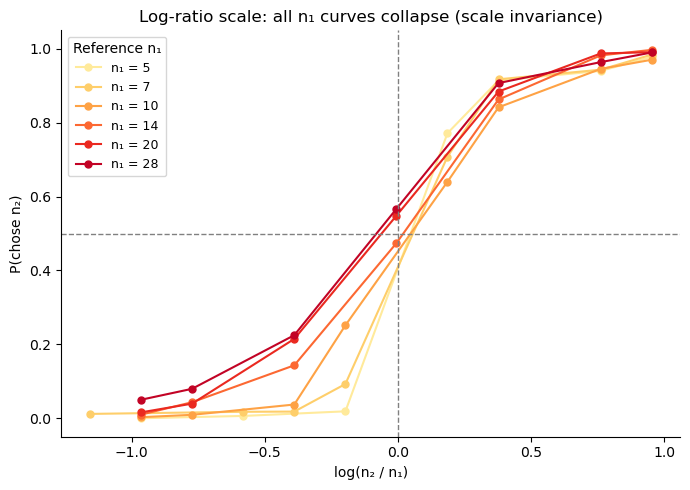

In [6]:
# Compute log-ratio for each trial and bin for plotting
data['log(n2/n1)'] = np.log(data['n2'] / data['n1'])
data['bin'] = (pd.cut(data['log(n2/n1)'], bins=12)
                 .map(lambda x: x.mid).astype(float))

grouped = (data.groupby(['n1', 'bin'])['choice']
               .agg(['mean', 'count']).reset_index()
               .query('count >= 5'))

n1_unique = sorted(grouped['n1'].unique())
pal_n1 = sns.color_palette('YlOrRd', len(n1_unique))
n1_colors = dict(zip(n1_unique, pal_n1))

fig, ax = plt.subplots(figsize=(7, 5))
for n1_val in n1_unique:
    d = grouped[grouped['n1'] == n1_val]
    ax.plot(d['bin'], d['mean'], 'o-', ms=5, lw=1.5,
            color=n1_colors[n1_val], label=f'n₁ = {n1_val}')
ax.axhline(.5, ls='--', c='gray', lw=1)
ax.axvline(.0, ls='--', c='gray', lw=1)
ax.set_ylim(-.05, 1.05)
ax.set_xlabel('log(n₂ / n₁)')
ax.set_ylabel('P(chose n₂)')
ax.set_title('Log-ratio scale: all n₁ curves collapse (scale invariance)')
ax.legend(title='Reference n₁', fontsize=9)
sns.despine(); plt.tight_layout()

The curves collapse when plotted against $\log(n_2/n_1)$, confirming the NLC
model's scale-invariance prediction.  The overlap is not perfect — small $n_1$ (5, 7)
produce slightly steeper curves, hinting at a mild departure from strict Weber's law
at low magnitudes.  Compare this with the natural-scale plots below.

## Weber's law: what linear encoding gets wrong

If we model choices in *natural* (linear) space and use a fixed noise $\nu$, the slope
of the psychometric function would be the same for all $n_1$ values.  But the data shows
a clear pattern: **steeper curves for small $n_1$, shallower for large $n_1$**.  This is
**Weber's law** — discrimination is proportionally harder for larger magnitudes.

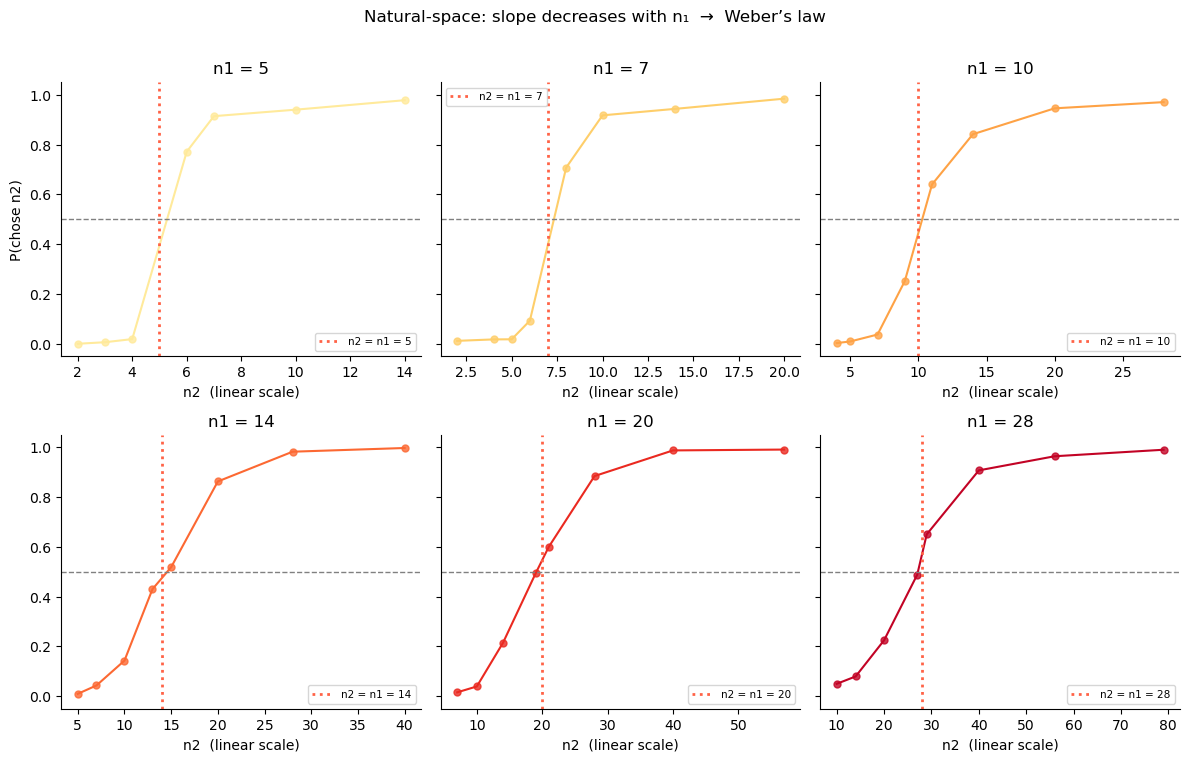

In [7]:
# Natural-space psychometric curves: slope and indifference point shift with n1
n1_unique = sorted(data['n1'].unique())
pal_n1 = sns.color_palette('YlOrRd', len(n1_unique))

fig, axes = plt.subplots(2, 3, figsize=(12, 7.5), sharey=True)
axes = axes.flatten()

for ax, n1_val, c in zip(axes, n1_unique, pal_n1):
    d_n1 = data[data['n1'] == n1_val]
    grp  = (d_n1.groupby('n2')['choice']
               .agg(['mean', 'count']).reset_index()
               .query('count >= 3'))
    ax.scatter(grp['n2'], grp['mean'], color=c, s=25, alpha=.8)
    ax.plot(grp['n2'], grp['mean'], color=c, lw=1.5)
    ax.axhline(.5, ls='--', c='gray', lw=1)
    ax.axvline(n1_val, ls=':', c='tomato', lw=2, label=f'n2 = n1 = {n1_val}')
    ax.set_title(f'n1 = {n1_val}')
    ax.set_xlabel('n2  (linear scale)')
    ax.set_ylim(-.05, 1.05)
    ax.legend(fontsize=7.5)
    sns.despine(ax=ax)

axes[0].set_ylabel('P(chose n2)')
plt.suptitle(
    'Natural-space: slope decreases with n₁  →  Weber’s law',
    fontsize=12, y=1.01)
plt.tight_layout()

### Recovering Weber's law non-parametrically

The NLC model assumes log-space encoding and derives Weber's law as a consequence.
But we can also test Weber's law *without* assuming log encoding, by fitting a model
that works in **natural space** — that is, the space of raw stimulus magnitudes $n$,
not $\log n$.

`PsychometricRegressionModel` is a simple psychometric-function model that takes two
stimuli $x_1, x_2$ and fits the probability of choosing $x_2$ as:

$$P(\text{chose}\; x_2) = \Phi\!\left(\frac{x_2 - x_1}{\nu}\right)$$

where the noise $\nu$ is now in the same units as $n$ (dots on screen), not in log-units.
By using `regressors={'nu': 'C(n1)'}`, we estimate a **separate $\nu$** for each reference
magnitude $n_1$ — no functional form is assumed.

If Weber's law holds, we expect $\nu(n_1) \propto n_1$: noise in natural space should
grow proportionally with magnitude.  This is the empirical signature of log-space encoding
when measured from outside, in the raw stimulus space.

In [8]:
from bauer.models import PsychometricRegressionModel

# x1 = n1, x2 = n2 in natural space (raw magnitudes, not log-transformed)
data_lin = data.copy()
data_lin['x1'] = data_lin['n1'].astype(float)
data_lin['x2'] = data_lin['n2'].astype(float)

# C(n1): categorical coding — separate nu per n1 level, no linearity assumption
model_lin_reg = PsychometricRegressionModel(
    paradigm=data_lin,
    regressors={'nu': 'C(n1)'},
)
model_lin_reg.build_estimation_model(data=data_lin, hierarchical=True)
idata_lin_reg = model_lin_reg.sample(draws=150, tune=150, chains=4, progressbar=False)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [nu_mu, nu_sd, nu_offset, bias_mu, bias_sd, bias_offset]


Sampling 4 chains for 150 tune and 150 draw iterations (600 + 600 draws total) took 62 seconds.


There was 1 divergence after tuning. Increase `target_accept` or reparameterize.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


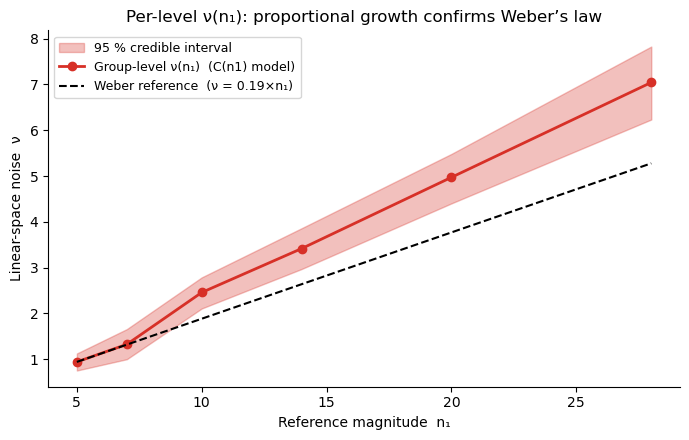

In [9]:
# Extract group-level nu at each unique n1 level via the model's design matrix
conditions_n1 = pd.DataFrame({'n1': n1_unique})
cond_pars = model_lin_reg.get_conditionwise_parameters(idata_lin_reg, conditions_n1, group=True)
nu_at_n1 = cond_pars.xs('nu', level='parameter')  # posterior samples × n1 levels

nu_mean = nu_at_n1.mean(0).values
nu_lo, nu_hi = np.percentile(nu_at_n1.values, [2.5, 97.5], axis=0)
n1_arr = np.array(n1_unique, dtype=float)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.fill_between(n1_arr, nu_lo, nu_hi, alpha=.30, color='#d73027', label='95 % credible interval')
ax.plot(n1_arr, nu_mean, lw=2, color='#d73027', marker='o', ms=6,
        label='Group-level ν(n₁)  (C(n1) model)')

# Weber's law reference: proportional noise  ν ∝ n1
k_weber = nu_mean[0] / n1_arr[0]
ax.plot(n1_arr, k_weber * n1_arr, '--k', lw=1.5,
        label=f'Weber reference  (ν = {k_weber:.2f}×n₁)')

ax.set_xlabel('Reference magnitude  n₁')
ax.set_ylabel('Linear-space noise  ν')
ax.set_title('Per-level ν(n₁): proportional growth confirms Weber’s law')
ax.legend(fontsize=9)
sns.despine()
plt.tight_layout()

**Key takeaway:** $\nu$ grows proportionally to $n_1$.  This is precisely **Weber's
law**, and it is *automatically* accounted for when noise is constant on a log scale (the
NLC model).  There is no need to model the $n_1$-dependence of noise explicitly: logarithmic
encoding produces it for free.  This is why `MagnitudeComparisonModel` works so well —
and why the next section fits it to the data.

## Fitting `MagnitudeComparisonModel` with bauer

### Why use bauer?

You could code a PyMC model by hand.  But bauer gives you:

| Feature | What it means in practice |
|---------|--------------------------|
| **One-line model construction** | `MagnitudeComparisonModel(paradigm=data)` |
| **Hierarchical structure automatically** | Group mean + between-subject SD inferred jointly with subject parameters |
| **Prior transforms baked in** | Noise parameters are always positive (softplus link), lapse rates in [0,1] |
| **Formula-based regression** | `regressors={'nu': 'C(condition)'}` — all patsy formulas work |
| **Built-in PPC** | `model.ppc(data, idata)` draws posterior-predictive choices |
| **ArviZ-native output** | All posteriors as `InferenceData`; use `az.plot_posterior`, `az.compare`, etc. directly |

### Why hierarchical modelling is essential

In a typical psychophysics experiment each participant sees a few hundred trials at most.
Fitting a multi-parameter cognitive model to 100--200 trials per subject gives very noisy,
often unidentifiable individual estimates.  The more expressive and theoretically
interesting the model, the worse this problem becomes: a 4-parameter model needs far more
data per subject than a 2-parameter model.

**Hierarchical (multilevel) modelling** solves this by assuming that participants are drawn
from a shared population.  Each subject $s$ gets their own parameters, but those parameters
are *regularised* toward the group mean — subjects with little data or extreme estimates
are pulled back toward the population, while subjects with lots of clear data are left
mostly alone.  This **partial pooling** gives you the best of both worlds:

- **Individual differences are preserved** — unlike a single group-level fit.
- **Noisy individuals are stabilised** — unlike fitting each subject independently.
- **Complex models become feasible** even at modest trial counts, because the group
  prior acts as a principled regulariser that prevents overfitting.

In practice, hierarchical fitting is what makes it possible to use models like the KLW
risk model (lesson 2) or the flexible-noise model (lesson 4) on real experimental data.
Without the group-level regularisation, the posterior for many subjects would be
dominated by the prior and the individual estimates would be meaningless.

### Hierarchical parameter structure in bauer

For the noise parameters, bauer sets up the hierarchy as:

$$\nu_k^{(s)} \sim \text{HalfNormal}(\mu_k,\, \sigma_k)$$

where $\mu_k$ (`n{k}_evidence_sd_mu`) is the **group mean** and $\sigma_k$
(`n{k}_evidence_sd_sd`) is the **between-subject spread**.  The posterior therefore
contains both the population-level estimate and the full distribution of individual
differences.

### MCMC sampling and posterior summaries

`.sample()` runs **Markov Chain Monte Carlo (MCMC)** — specifically, PyMC's No-U-Turn
Sampler (NUTS).  MCMC generates a large collection of *samples* that, after a warm-up
("tuning") phase, are drawn proportionally to the posterior probability.  The key idea:
rather than returning a single best-fit value, MCMC gives you a *distribution* over
parameter values that reflects both what the data support and how uncertain we are.

Two numbers summarise that distribution most usefully:
- **Posterior mean** — the expected value of the parameter.
- **Highest Density Interval (HDI)** — the shortest interval containing a given
  probability mass (typically 94 % or 95 %).  Unlike a frequentist confidence interval,
  the HDI can be read directly: *"there is 94 % posterior probability that the true
  value lies in this range."*

ArviZ's `az.plot_posterior` displays both automatically.  bauer exposes the samples as
an `arviz.InferenceData` object so all ArviZ diagnostics work out-of-the-box.

In [10]:
model_mag = MagnitudeComparisonModel(paradigm=data)
model_mag.build_estimation_model(data=data, hierarchical=True, save_p_choice=True)
idata_mag = model_mag.sample(draws=200, tune=200, chains=4, progressbar=False)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [n1_evidence_sd_mu_untransformed, n1_evidence_sd_sd, n1_evidence_sd_offset, n2_evidence_sd_mu_untransformed, n2_evidence_sd_sd, n2_evidence_sd_offset]


Sampling 4 chains for 200 tune and 200 draw iterations (800 + 800 draws total) took 46 seconds.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


### Group-level posteriors

`az.plot_posterior` gives us the group-level posteriors for $\nu_1$ and $\nu_2$.
The 94 % HDI quantifies our uncertainty about the group mean.  We expect $\nu_1 > \nu_2$
because of working-memory degradation for the first-presented option.

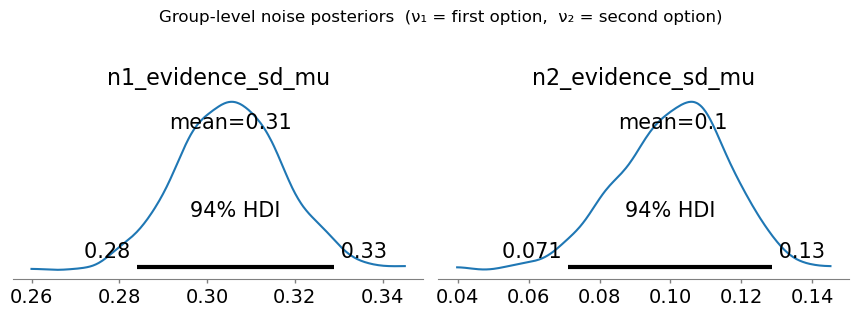

In [11]:
az.plot_posterior(
    idata_mag,
    var_names=['n1_evidence_sd_mu', 'n2_evidence_sd_mu'],
    figsize=(9, 3),
)
plt.suptitle('Group-level noise posteriors  (ν₁ = first option,  ν₂ = second option)', y=1.04)
plt.tight_layout()

The group-level posterior for $\nu_1$ (`n1_evidence_sd_mu`) is consistently **larger**
than for $\nu_2$ (`n2_evidence_sd_mu`) — working-memory degradation in action.

### Individual subject estimates with 95 % credible intervals

The posterior also contains a full distribution for **each individual subject**.  bauer
provides two complementary tools:

- `plot_subjectwise_parameters(idata, parameter, ax=ax)` — direct call for a single parameter
- `get_subject_posterior_df(idata, parameters)` + `plot_subjectwise_pointplot` — tidy
  DataFrame workflow compatible with `sns.FacetGrid` (supports hue, facetting, etc.)

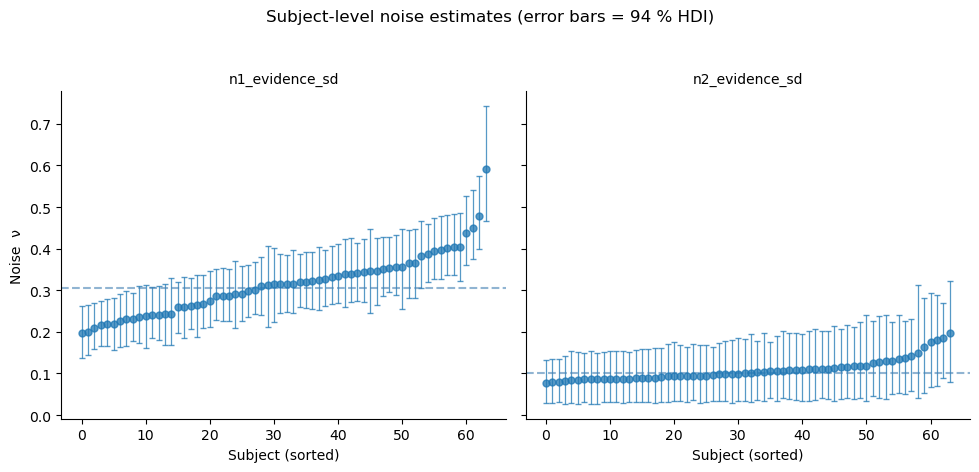

In [12]:
from bauer.utils import (plot_subjectwise_parameters,
                          get_subject_posterior_df, plot_subjectwise_pointplot)

# ── FacetGrid workflow: one panel per parameter ───────────────────────────────
df_post = get_subject_posterior_df(
    idata_mag, ['n1_evidence_sd', 'n2_evidence_sd'])

g = sns.FacetGrid(df_post, col='parameter', sharey=True, height=4.5, aspect=1.1)
g.map_dataframe(plot_subjectwise_pointplot)  # uses default mean_col='mean', lo_col='lo', hi_col='hi'
g.set_axis_labels('Subject (sorted)', 'Noise  ν')
g.set_titles(col_template='{col_name}')
g.figure.suptitle('Subject-level noise estimates (error bars = 94 % HDI)', y=1.04)

# Add group-mean line to each panel
for ax, param in zip(g.axes.flat, ['n1_evidence_sd', 'n2_evidence_sd']):
    mu_key = param + '_mu'
    if mu_key in idata_mag.posterior:
        gm = idata_mag.posterior[mu_key].values.mean()
        ax.axhline(gm, ls='--', lw=1.5, alpha=0.6, color='steelblue',
                   label='Group mean')
    sns.despine(ax=ax)

plt.tight_layout()

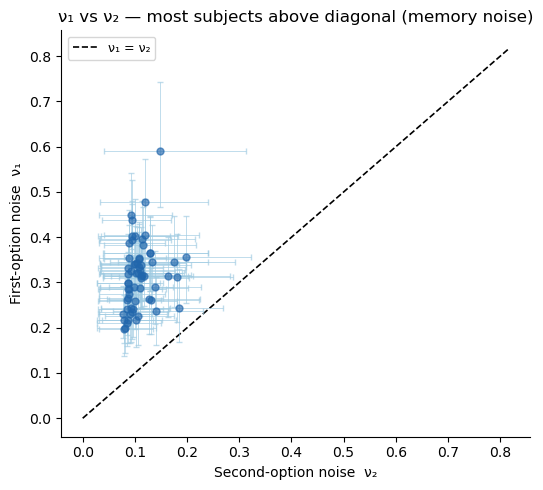

In [13]:
# ── Scatter: ν₁ vs ν₂ per subject with 94 % HDI error bars ───────────────────
n_subj = idata_mag.posterior['n1_evidence_sd'].shape[-1]
s1 = idata_mag.posterior['n1_evidence_sd'].values.reshape(-1, n_subj)
s2 = idata_mag.posterior['n2_evidence_sd'].values.reshape(-1, n_subj)
nu1_mean, nu2_mean = s1.mean(0), s2.mean(0)
nu1_lo, nu1_hi = np.percentile(s1, [3, 97], axis=0)
nu2_lo, nu2_hi = np.percentile(s2, [3, 97], axis=0)

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.errorbar(nu2_mean, nu1_mean,
            xerr=[nu2_mean - nu2_lo, nu2_hi - nu2_mean],
            yerr=[nu1_mean - nu1_lo, nu1_hi - nu1_mean],
            fmt='o', ms=5, alpha=.65, elinewidth=0.7, capsize=2.5,
            color='#2166ac', ecolor='#9ecae1', zorder=3)
lim = max(nu1_hi.max(), nu2_hi.max()) * 1.1
ax.plot([0, lim], [0, lim], 'k--', lw=1.2, label='ν₁ = ν₂')
ax.set_xlabel('Second-option noise  ν₂')
ax.set_ylabel('First-option noise  ν₁')
ax.set_title('ν₁ vs ν₂ — most subjects above diagonal (memory noise)')
ax.legend(fontsize=9); sns.despine(ax=ax)
plt.tight_layout()

## Posterior predictive check

We draw predicted choice probabilities from the full posterior and overlay the 95 %
credible interval on the observed group-average data (one panel per $n_1$ value).
A good fit means the shaded band covers the observed dots — and the model should also
capture the different slopes across $n_1$ values (the Weber's-law signature).

Sampling: [ll_bernoulli]


Output()

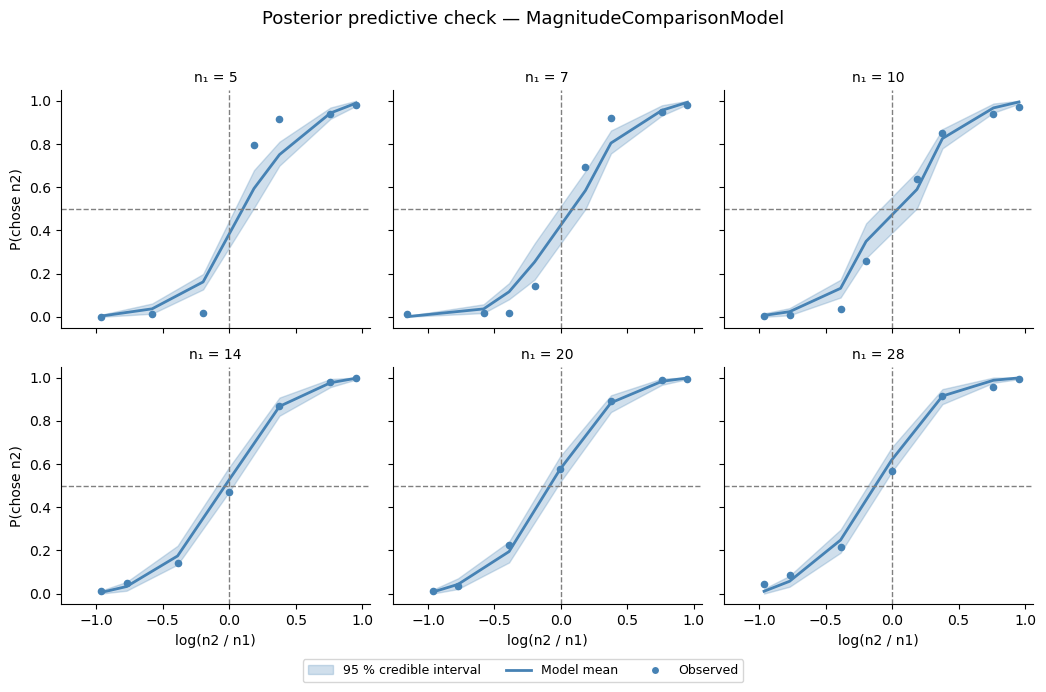

In [14]:
from bauer.utils import summarize_ppc_group

# Simulate binary choices from the posterior predictive
ppc_df  = model_mag.ppc(data, idata_mag, var_names=['ll_bernoulli'])
ppc_ll  = ppc_df.xs('ll_bernoulli', level='variable')   # trials × posterior samples

ppc_flat = ppc_ll.reset_index()
ppc_flat['bin'] = (pd.cut(-ppc_flat['log(n1/n2)'], 12)
                     .map(lambda x: x.mid).astype(float))

g_ppc = summarize_ppc_group(ppc_flat, condition_cols=['n1', 'bin'])
g_ppc = g_ppc.rename(columns={'p_predicted': 'p_mean', 'hdi025': 'p_lo', 'hdi975': 'p_hi'})

data_copy = data.reset_index()
data_copy['bin'] = (pd.cut(-data_copy['log(n1/n2)'], 12)
                      .map(lambda x: x.mid).astype(float))
obs = (data_copy.groupby(['subject', 'n1', 'bin'])['choice'].mean()
                .groupby(['n1', 'bin']).mean())
g_ppc['choice'] = obs
g_ppc = g_ppc.reset_index()

import matplotlib.patches as mpatches

def draw_ppc(data, **kwargs):
    ax = plt.gca()
    ax.fill_between(data['bin'], data['p_lo'], data['p_hi'],
                    color='steelblue', alpha=.25)
    ax.plot(data['bin'], data['p_mean'], color='steelblue', lw=2)
    ax.scatter(data['bin'], data['choice'], color='steelblue', s=20, zorder=5)
    ax.axhline(.5, ls='--', c='gray', lw=1)
    ax.axvline(0,  ls='--', c='gray', lw=1)
    ax.set_ylim(-.05, 1.05)

g = sns.FacetGrid(g_ppc, col='n1', col_wrap=3, height=3.2, aspect=1.1, sharey=True)
g.map_dataframe(draw_ppc)
g.set_axis_labels('log(n2 / n1)', 'P(chose n2)')
g.set_titles('n₁ = {col_name}')
for ax in g.axes.flat:
    sns.despine(ax=ax)

legend_handles = [
    mpatches.Patch(color='steelblue', alpha=.25, label='95 % credible interval'),
    plt.Line2D([0], [0], color='steelblue', lw=2, label='Model mean'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue',
               markersize=6, label='Observed'),
]
g.figure.legend(handles=legend_handles, loc='lower center', ncol=3,
                fontsize=9, bbox_to_anchor=(.5, -.04))
g.figure.suptitle('Posterior predictive check — MagnitudeComparisonModel',
                   fontsize=13, y=1.02)
g.figure.tight_layout()

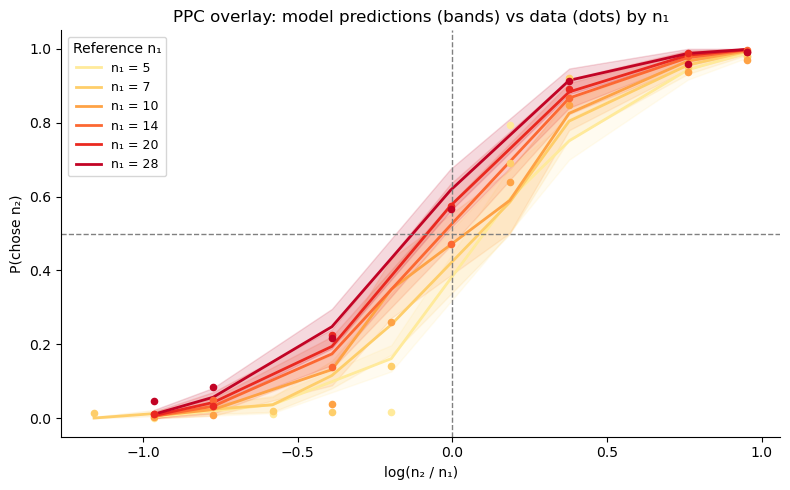

In [15]:
# PPC overlay: all n1 values in one panel (hue = n1)
n1_pal = sns.color_palette('YlOrRd', g_ppc['n1'].nunique())
n1_colors = dict(zip(sorted(g_ppc['n1'].unique()), n1_pal))

fig, ax = plt.subplots(figsize=(8, 5))
for n1_val in sorted(g_ppc['n1'].unique()):
    d = g_ppc[g_ppc['n1'] == n1_val].sort_values('bin')
    c = n1_colors[n1_val]
    ax.fill_between(d['bin'], d['p_lo'], d['p_hi'], alpha=.15, color=c)
    ax.plot(d['bin'], d['p_mean'], lw=2, color=c, label=f'n₁ = {n1_val}')
    ax.scatter(d['bin'], d['choice'], s=20, color=c, zorder=5)
ax.axhline(.5, ls='--', c='gray', lw=1)
ax.axvline(0,  ls='--', c='gray', lw=1)
ax.set_ylim(-.05, 1.05)
ax.set_xlabel('log(n₂ / n₁)')
ax.set_ylabel('P(chose n₂)')
ax.set_title('PPC overlay: model predictions (bands) vs data (dots) by n₁')
ax.legend(title='Reference n₁', fontsize=9)
sns.despine(); plt.tight_layout()

## Summary

In this lesson we built up the NLC model from first principles:

1. **Logarithmic encoding** of numerical magnitudes, with Gaussian noise $\nu$.
2. **Scale invariance**: the psychometric function collapses to a single sigmoid on the
   log-ratio axis.
3. **Noise level** controls slope; **asymmetric noise** ($\nu_1 > \nu_2$) flattens the
   curve without shifting it.
4. **Bayesian prior** produces the central tendency bias; asymmetric noise interacting
   with the prior creates **magnitude–order interactions**.
5. **Weber's law** falls out automatically from log-space encoding.
6. bauer fits all parameters hierarchically in a few lines, yielding full posterior
   distributions at both the group and individual-subject level.

In [Lesson 2](lesson2.ipynb) we move to **risky choice** and see how the same perceptual
noise parameters that distort magnitude perception also drive risk attitudes.